In [781]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import control as ct

In [782]:
#Параметры иходной системы

J0 = 0.25
Q = 4.8
Q1 = 200
m = 0.12
R = 16
L = 0.12

In [783]:
#Исходная система

def initial_system(t, state_vector, u_func):
  y, v, j = state_vector
  u = u_func(t)

  dy_dt = v
  dv_dt = (J0 * Q1 / m) * y + (Q / m) * j
  dj_dt = -(Q / L) * v - (R/ L) * j + u / L

  return [dy_dt, dv_dt, dj_dt]

In [784]:
#Параметры переобозначенной системы
m1 = J0 * Q1 / m
m2 = Q / m
l1 = Q / L
l2 = R/ L

In [785]:
#Переобозначенная система

def system(t, state_vector, u_func):

  x1, x2, x3 = state_vector
  u1 = u_func(t) / L

  dx1_dt = x2
  dx2_dt = m1 * x1 + m2 * x3
  dx3_dt = -l1 * x2 - l2 * x3 + u1

  return [dx1_dt, dx2_dt, dx3_dt]

In [786]:
#Матрицы системы

A = np.array([
  [0, 1, 0 ],
  [m1, 0, m2], 
  [0, -l1, -l2]
])

B = np.array([
  [0], 
  [0], 
  [1]
])

H = np.array([[0, 0, 1]])

In [ ]:
#Проверка неустойчивсти системы при u1 = 0
print(np.linalg.eigvals(A))

if(any(np.linalg.eigvals(A)) > 0):
  print("\nСистема неустойчива")
else:
  print("Систсема устойчива")

[  15.73956373  -29.525267   -119.54763006]

Система неустойчива


In [788]:
#Проверка управляемости и наблюдаемости

rank_control = np.linalg.matrix_rank(ct.ctrb(A, B))

if rank_control == A.shape[0]:
  print(f"Система полностью управляема, ранг U = {rank_control}")
else:
  print(f"Полной управляемости нет, ранг U = {rank_control}")

rank_observability = np.linalg.matrix_rank(ct.obsv(A, H))

if rank_observability == A.shape[0]:
  print(f"Система полностью наблюдаема, ранг N = {rank_observability}")
else:
  print(f"Полной наблюдаемости нет, ранг N = {rank_observability}")
  

Система полностью управляема, ранг U = 3
Система полностью наблюдаема, ранг N = 3


In [789]:
#Ищем через LQR коэффициенты матрицы для обратной связи для управления 
Q = np.diag([10.0, 50.0, 1]) #координата, скорость, сила тока
R = np.array([0.1])
K, _, _ = ct.lqr(A, B, Q, R)

print(K)
print(np.linalg.eigvals(A - B @ K))

[[3111.05298048  119.14936869   31.95346975]]
[-119.33546794  -15.089141    -30.86219414]


In [790]:
#Ищем матрицу оценивателя (L)
#LQR (Linear Quadratic Regulator) для управления минимизирует J = \int(x.T Q x + u.T R u)dt (A - BC) подбирает такое C => для дуальной системы подбирает такое L, что ошибки оценки стремятся к 0 (A - LH), минимизируя
#J_dual = \int(z.T Q_obs z + u_dual.T R_obs u_dual) dt

In [ ]:
#Q_obs - "доверие к модели"
#Большое Q_obs = модель неточная, нужна быстрая коррекция

#R_obs - "доверие к измерениям"
#Большое R_obs = измерения шумные, медленно их учитываем

measurement_noise_std = 0.1  # среднеквадратичное отклонение шума измерения
control_noise_std = 0.01

Q_obs = np.eye(3) * 10   # как быстро верить модели
R_obs = np.eye(1) * 0.001 # как сильно верить измерениям

#R_obs = np.eye(1) * (measurement_noise_std ** 2)

L_T, _, _ = ct.lqr(A.T, H.T, Q_obs, R_obs)
L = L_T.T

In [792]:
print(f"L = {L}\n")
print(f"Собственные числа матрицы (A - L @ H): {np.linalg.eigvals(A - L @ H)}")

L = [[-107.58440493]
 [-777.06899565]
 [ 166.57214749]]

Собственные числа матрицы (A - L @ H): [ -66.89293335+74.61214429j  -66.89293335-74.61214429j
 -166.11961413 +0.j        ]


In [793]:
#Замкнутая система

def closed_system(t, state):
    x = state[:3]      
    x_est = state[3:]  
    
    z_true = (H @ x).item()
    z_measured = z_true + measurement_noise_std * np.random.randn() #белый шум, нормальное распределение
    
    u_true = -(K @ x_est).item()
    u_given = u_true + control_noise_std * np.random.randn()
    
    dxdt = A @ x + (B.flatten() * u_given)
    dx_estdt = A @ x_est + (B.flatten() * u_given) + (L.flatten() * (z_measured - (H @ x_est).item()))
    
    return np.concatenate([dxdt, dx_estdt]) #вертикально

In [794]:
#Проверка устойчивости замкнутой системы
A_closed = np.block([
  [A, -B @ K],
  [L @ H, A - B @ K - L @ H]
])

print(np.linalg.eigvals(A_closed))


[ -66.89293335+74.61214429j  -66.89293335-74.61214429j
 -166.11961413 +0.j         -119.33546794 +0.j
  -15.089141   +0.j          -30.86219414 +0.j        ]


In [795]:
#Решение замкнутой системы

x0 = np.array([1.0, 1.0, 1.0])     
x0_est = np.array([2.0, 2.0, 2.0])  
state0 = np.concatenate([x0, x0_est])

t_span = (0, 0.5)
t_eval = np.linspace(0, 0.5, 100)

sol = solve_ivp(
    closed_system, 
    t_span, 
    state0, 
    t_eval=t_eval
)

In [796]:
t = sol.t
x_real = sol.y[:3, :] 
x_est = sol.y[3:, :]   

u_true_history = []
u_given_history = []

for i in range(len(t)):
    u_true = -K @ x_est[:, i]
    u_true_val = u_true.item() if hasattr(u_true, 'item') else u_true[0]
    u_given_val = u_true_val + control_noise_std * np.random.randn()
    
    u_true_history.append(u_true_val)
    u_given_history.append(u_given_val)

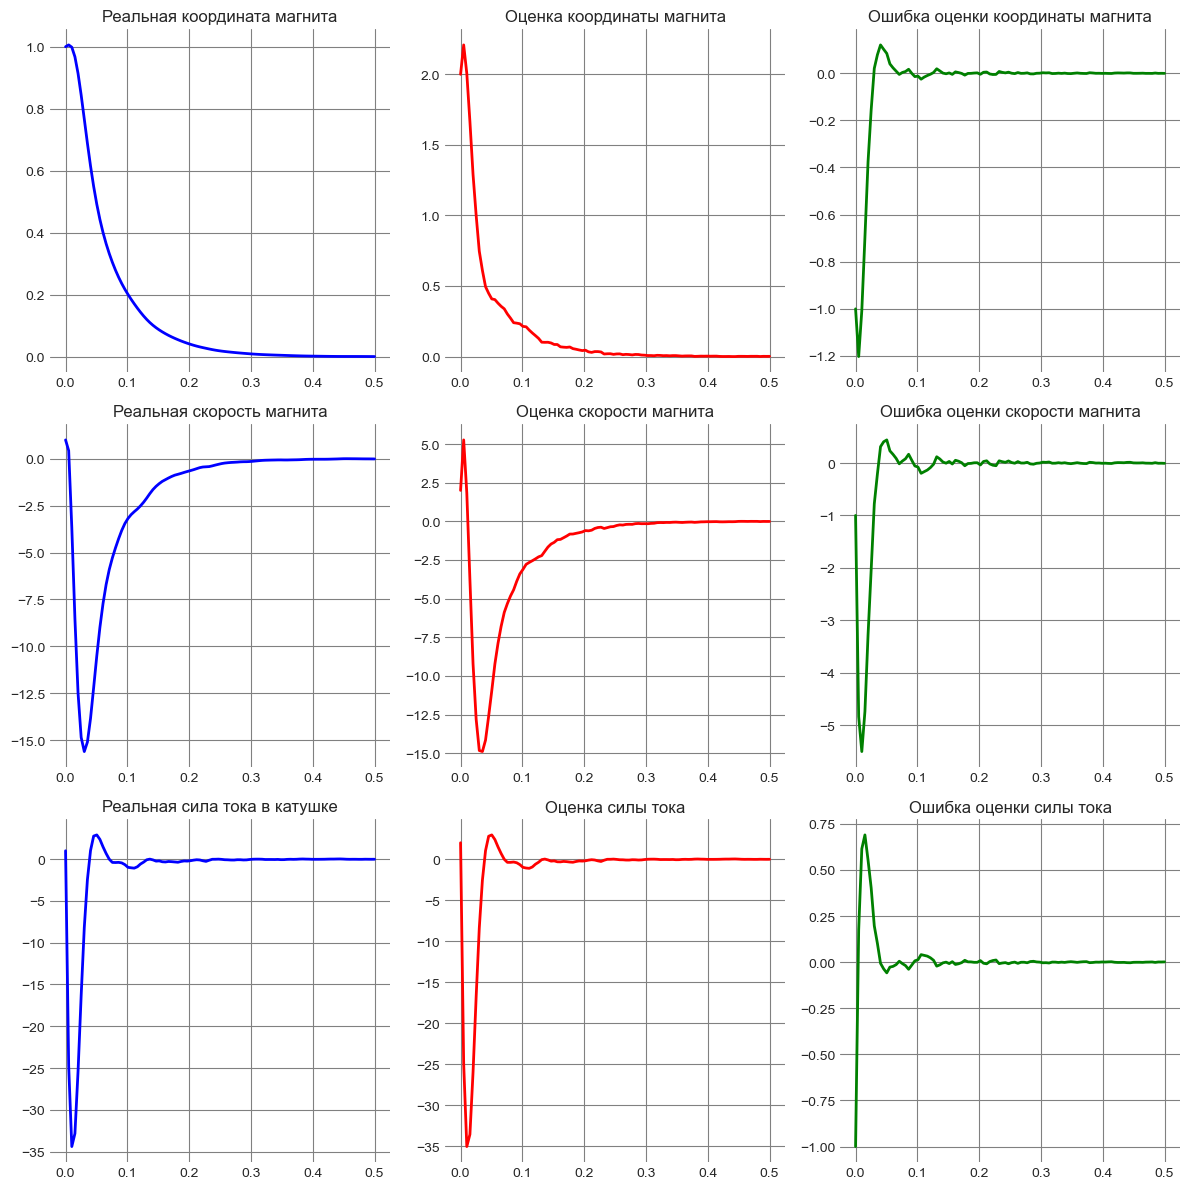

In [797]:
fig, axes = plt.subplots(3, 3, figsize = (12, 12))

for i in range(3):
    for j in range(3):
        axes[i, j].set_facecolor('none')
        axes[i, j].patch.set_alpha(0)

# Состояние x1
axes[0, 0].set_title('Реальная координата магнита')
axes[0, 0].plot(t, x_real[0, :], 'b-', linewidth = 2, label = 'x1')
axes[0, 0].grid(True, color = 'gray')

axes[0, 1].set_title('Оценка координаты магнита')
axes[0, 1].plot(t, x_est[0, :], 'r-', linewidth = 2, label = 'x1')
axes[0, 1].grid(True, color = 'gray')

axes[0, 2].set_title('Ошибка оценки координаты магнита')
axes[0, 2].plot(t, x_real[0, :] - x_est[0, :], 'g-', linewidth = 2, label = 'x1')
axes[0, 2].grid(True, color='gray')

# Состояние x2
axes[1, 0].set_title('Реальная скорость магнита')
axes[1, 0].plot(t, x_real[1, :], 'b-', linewidth = 2, label = 'x1')
axes[1, 0].grid(True, color='gray')

axes[1, 1].set_title('Оценка скорости магнита')
axes[1, 1].plot(t, x_est[1, :], 'r-', linewidth = 2, label = 'x1')
axes[1, 1].grid(True, color='gray')

axes[1, 2].set_title('Ошибка оценки скорости магнита')
axes[1, 2].plot(t, x_real[1, :] - x_est[1, :], 'g-', linewidth = 2, label = 'x1')
axes[1, 2].grid(True, color='gray')

# Состояние x3
axes[2, 0].set_title('Реальная сила тока в катушке')
axes[2, 0].plot(t, x_real[2, :], 'b-', linewidth = 2, label = 'x1')
axes[2, 0].grid(True, color='gray')

axes[2, 1].set_title('Оценка силы тока')
axes[2, 1].plot(t, x_est[2, :], 'r-', linewidth = 2, label = 'x1')
axes[2, 1].grid(True, color='gray')

axes[2, 2].set_title('Ошибка оценки силы тока')
axes[2, 2].plot(t, x_real[2, :] - x_est[2, :], 'g-', linewidth = 2, label = 'x1')
axes[2, 2].grid(True, color='gray')

plt.tight_layout()
plt.show()



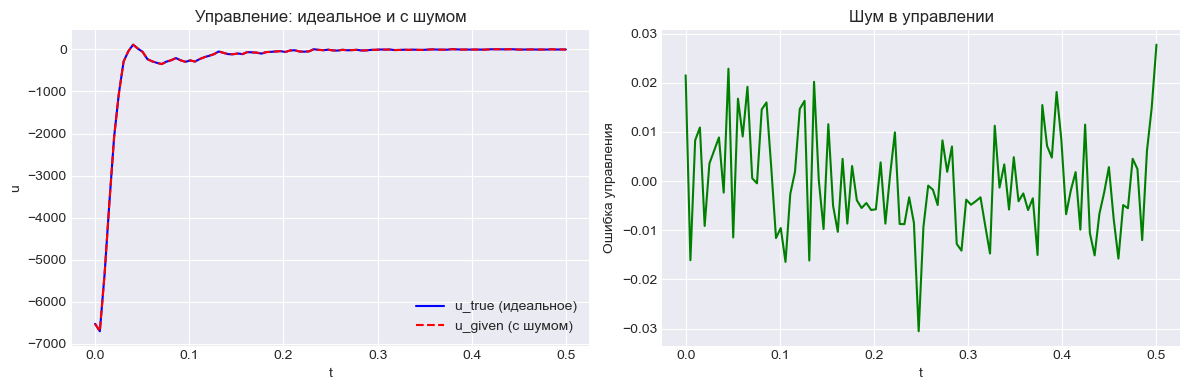

In [798]:
plt.figure(figsize = (12, 4))
plt.subplot(1, 2, 1)
plt.plot(t, u_true_history, 'b-', label = 'u_true (идеальное)')
plt.plot(t, u_given_history, 'r--', label = 'u_given (с шумом)')
plt.grid(True)
plt.xlabel('t')
plt.ylabel('u')
plt.legend()
plt.title('Управление: идеальное и с шумом')

plt.subplot(1, 2, 2)
plt.plot(t, np.array(u_given_history) - np.array(u_true_history), 'g-')
plt.grid(True)
#plt.ylim(-1, 1)
plt.xlabel('t')
plt.ylabel('Ошибка управления')
plt.title('Шум в управлении')
plt.tight_layout()
plt.show()

c:\Users\1\Documents\anacona\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


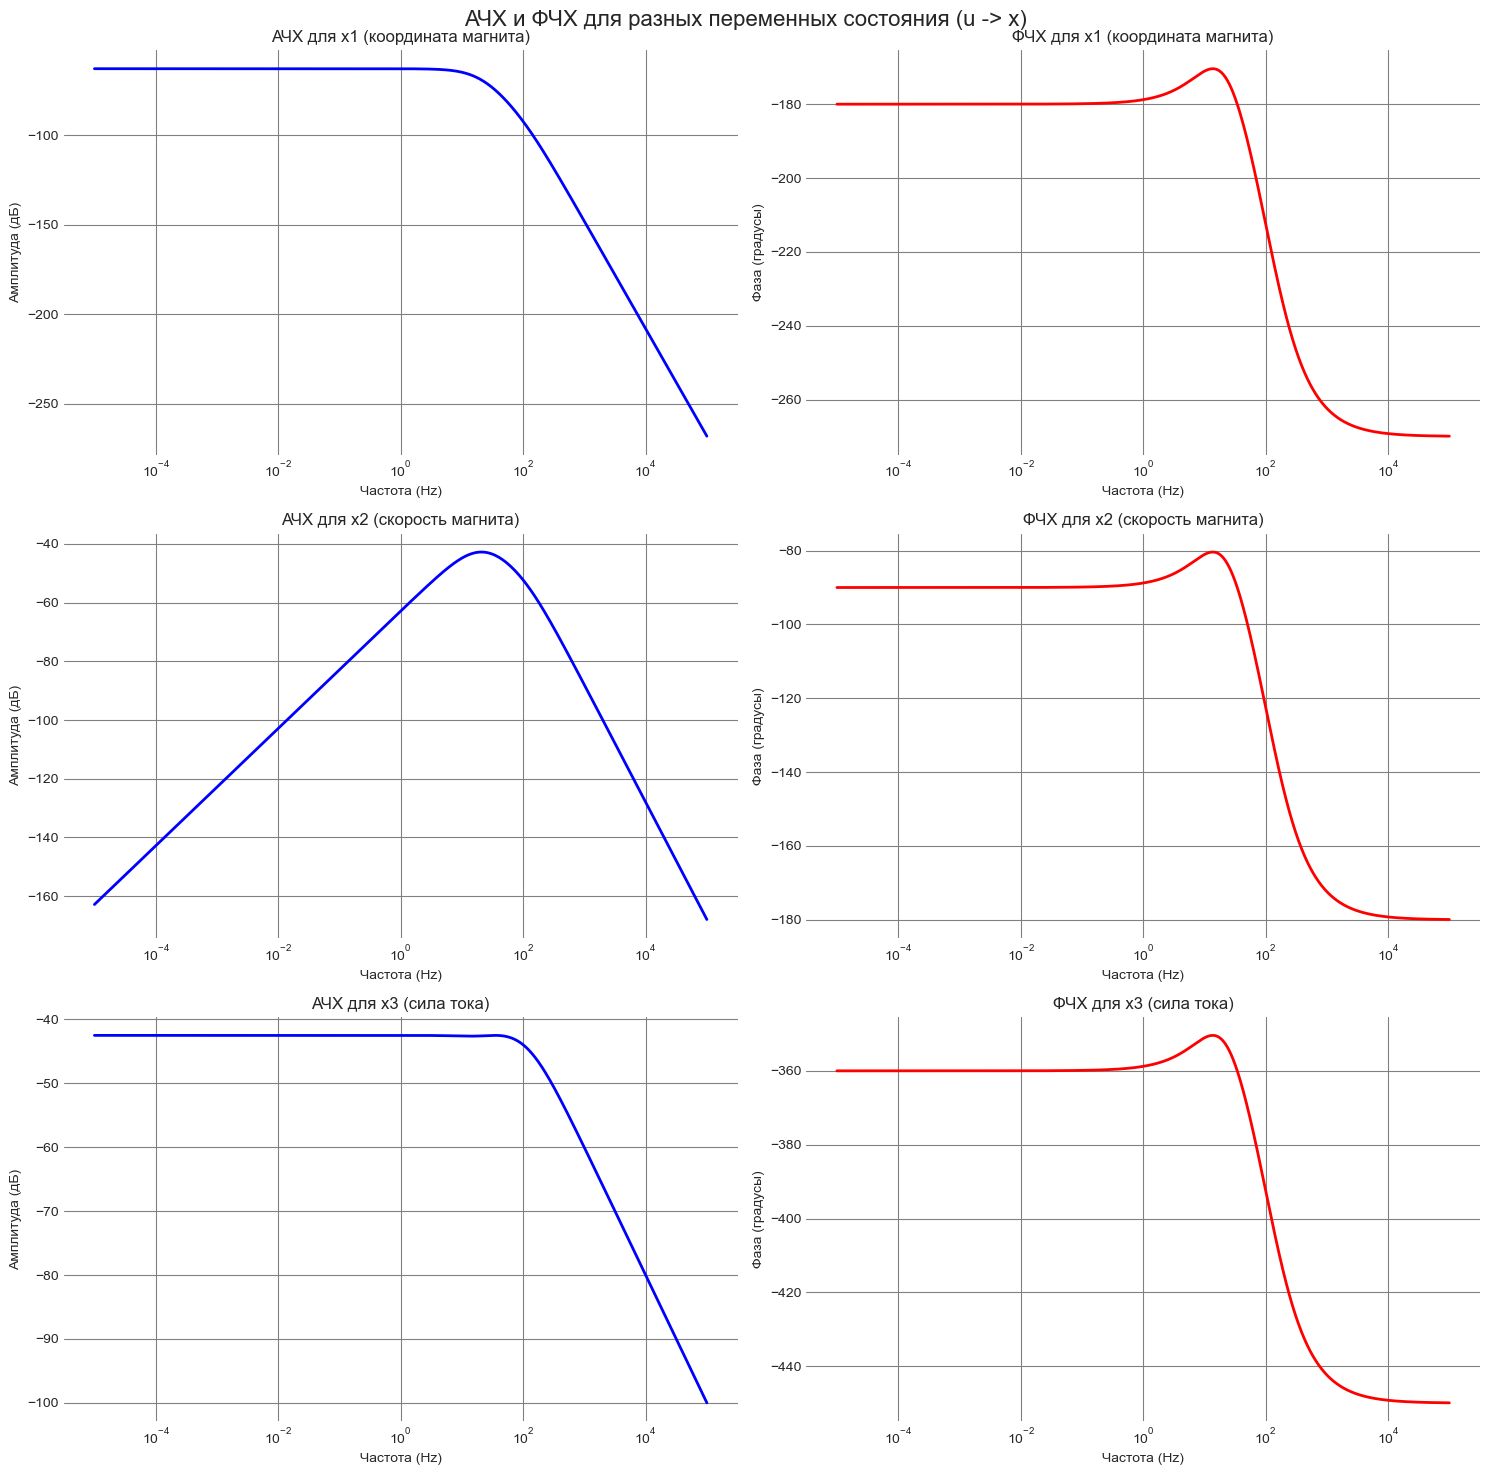

In [ ]:
D = np.array([[0]])

C_x1 = np.array([[1, 0, 0]])
sys_x1 = ct.ss(A, B, C_x1, D)

C_x2 = np.array([[0, 1, 0]]) 
sys_x2 = ct.ss(A, B, C_x2, D)

C_x3 = np.array([[0, 0, 1]]) 
sys_x3 = ct.ss(A, B, C_x3, D)


fig, axes = plt.subplots(3, 2, figsize = (15, 15))
fig.suptitle('АЧХ и ФЧХ для разных переменных состояния (u -> x)', fontsize = 16)

for i in range(3):
    for j in range(2):
        axes[i, j].set_facecolor('none')
        axes[i, j].patch.set_alpha(0)

#Частотный диапазон
omega = np.logspace(-5, 5, 1000)

systems = [sys_x1, sys_x2, sys_x3]
titles = ['x1 (координата магнита)', 'x2 (скорость магнита)', 'x3 (сила тока)']

for i, (sys, title) in enumerate(zip(systems, titles)):

    mag, phase, omega = ct.bode(sys, omega, dB = True, Hz = True, plot = False)
    
    # График АЧХ
    axes[i, 0].semilogx(omega, 20 * np.log10(mag.flatten()), 'b-', linewidth=2)
    axes[i, 0].grid(True, color = 'gray')
    axes[i, 0].set_ylabel('Амплитуда (дБ)')
    axes[i, 0].set_title(f'АЧХ для {title}')
    axes[i, 0].set_xlabel('Частота (Hz)')
    
    # График ФЧХ
    axes[i, 1].semilogx(omega, phase.flatten() * 180/np.pi, 'r-', linewidth=2)
    axes[i, 1].grid(True, color = 'gray')
    axes[i, 1].set_ylabel('Фаза (градусы)')
    axes[i, 1].set_title(f'ФЧХ для {title}')
    axes[i, 1].set_xlabel('Частота (Hz)')

plt.tight_layout()
plt.show()

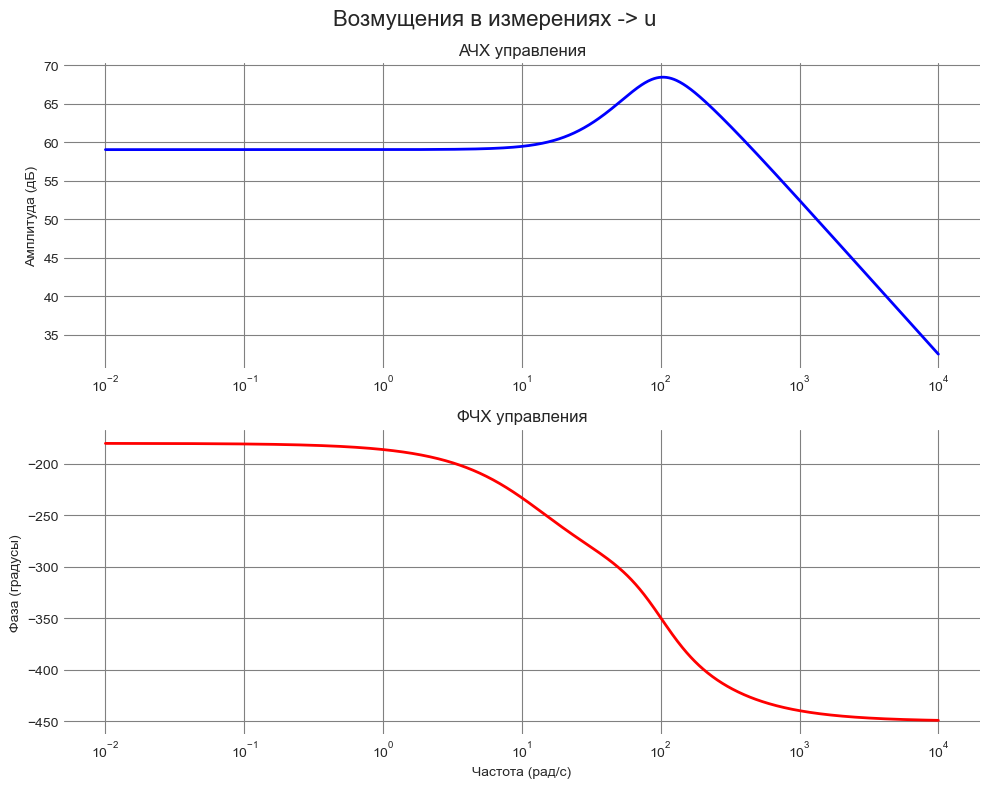

In [800]:
#АЧХ и ФЧХ управления (возмущения в измерениях -> u)

C_u = np.block([np.zeros((1, 3)), -K])  # [0 0 0 | -K]
D_u = np.array([[0]])

B_z = np.vstack([np.zeros((3, 1)), L]) #L(Hx + r)

sys_u = ct.ss(A_closed, B_z, C_u, D_u)

omega = np.logspace(-2, 4, 1000)  

mag_u, phase_u, omega_u = ct.bode(sys_u, omega, dB = True, Hz = True, plot = False)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle('Возмущения в измерениях -> u', fontsize = 16)

for i in range(2):
    axes[i].set_facecolor('none')
    axes[i].patch.set_alpha(0)

axes[0].semilogx(omega_u, 20 * np.log10(mag_u.flatten()), 'b-', linewidth = 2)
axes[0].grid(True, color = 'gray')
axes[0].set_ylabel('Амплитуда (дБ)')
axes[0].set_title('АЧХ управления')

axes[1].semilogx(omega_u, phase_u.flatten() * 180/np.pi, 'r-', linewidth = 2)
axes[1].grid(True, color = 'gray')
axes[1].set_xlabel('Частота (рад/с)')
axes[1].set_ylabel('Фаза (градусы)')
axes[1].set_title('ФЧХ управления')

plt.tight_layout()
plt.show()

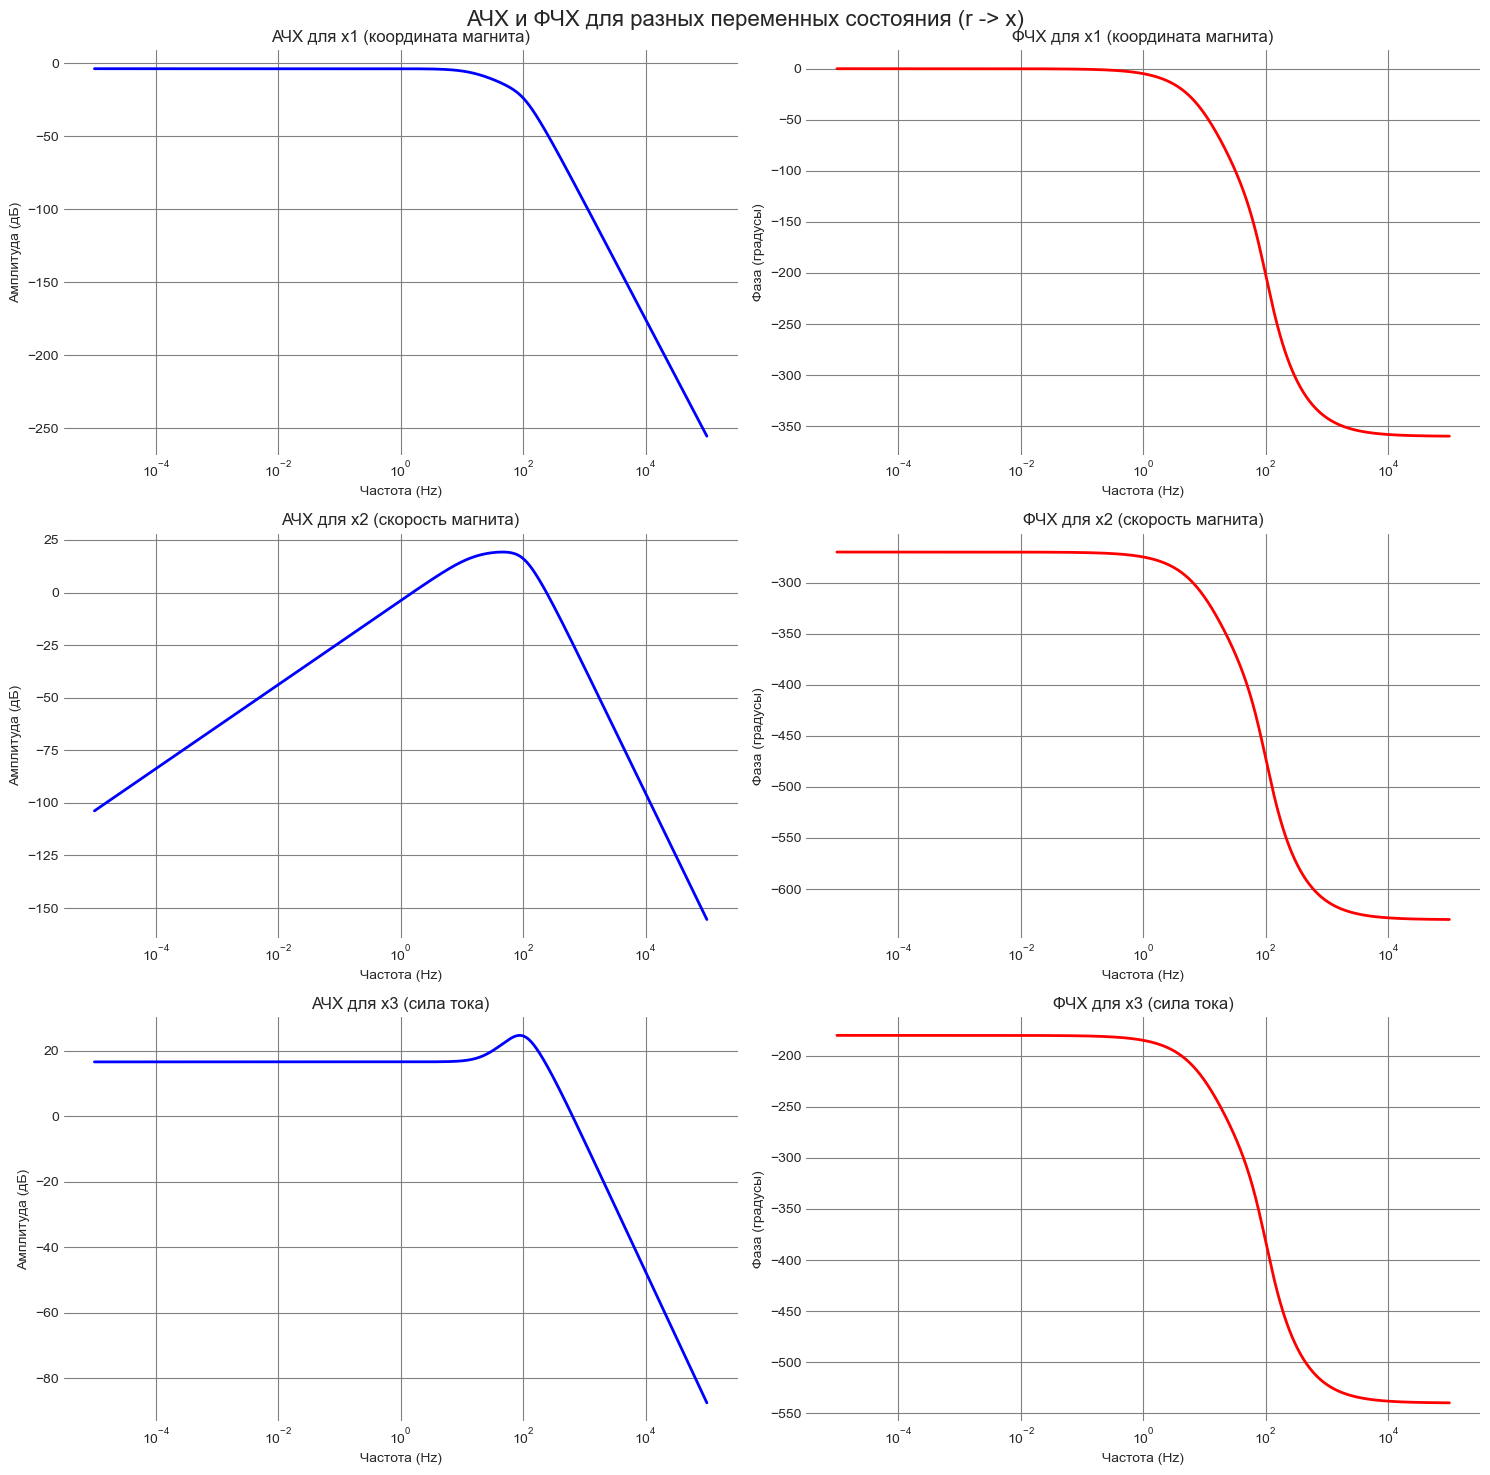

In [801]:
C_x1_z = np.hstack([C_x1, np.zeros((1, 3))])
C_x2_z = np.hstack([C_x2, np.zeros((1, 3))])
C_x3_z = np.hstack([C_x3, np.zeros((1, 3))])

sys_z_x1 = ct.ss(A_closed, B_z, C_x1_z, D)
sys_z_x2 = ct.ss(A_closed, B_z, C_x2_z, D)
sys_z_x3 = ct.ss(A_closed, B_z, C_x3_z, D)

fig, axes = plt.subplots(3, 2, figsize = (15, 15))
fig.suptitle('АЧХ и ФЧХ для разных переменных состояния (r -> x)', fontsize = 16)

for i in range(3):
    for j in range(2):
        axes[i, j].set_facecolor('none')
        axes[i, j].patch.set_alpha(0)

#Частотный диапазон
omega = np.logspace(-5, 5, 1000)

systems_z = [sys_z_x1, sys_z_x2, sys_z_x3]
titles = ['x1 (координата магнита)', 'x2 (скорость магнита)', 'x3 (сила тока)']

for i, (sys, title) in enumerate(zip(systems_z, titles)):

    mag, phase, omega = ct.bode(sys, omega, dB = True, Hz = True, plot = False)
    
    # График АЧХ
    axes[i, 0].semilogx(omega, 20 * np.log10(mag.flatten()), 'b-', linewidth=2)
    axes[i, 0].grid(True, color = 'gray')
    axes[i, 0].set_ylabel('Амплитуда (дБ)')
    axes[i, 0].set_title(f'АЧХ для {title}')
    axes[i, 0].set_xlabel('Частота (Hz)')
    
    # График ФЧХ
    axes[i, 1].semilogx(omega, phase.flatten() * 180/np.pi, 'r-', linewidth=2)
    axes[i, 1].grid(True, color = 'gray')
    axes[i, 1].set_ylabel('Фаза (градусы)')
    axes[i, 1].set_title(f'ФЧХ для {title}')
    axes[i, 1].set_xlabel('Частота (Hz)')

plt.tight_layout()
plt.show()

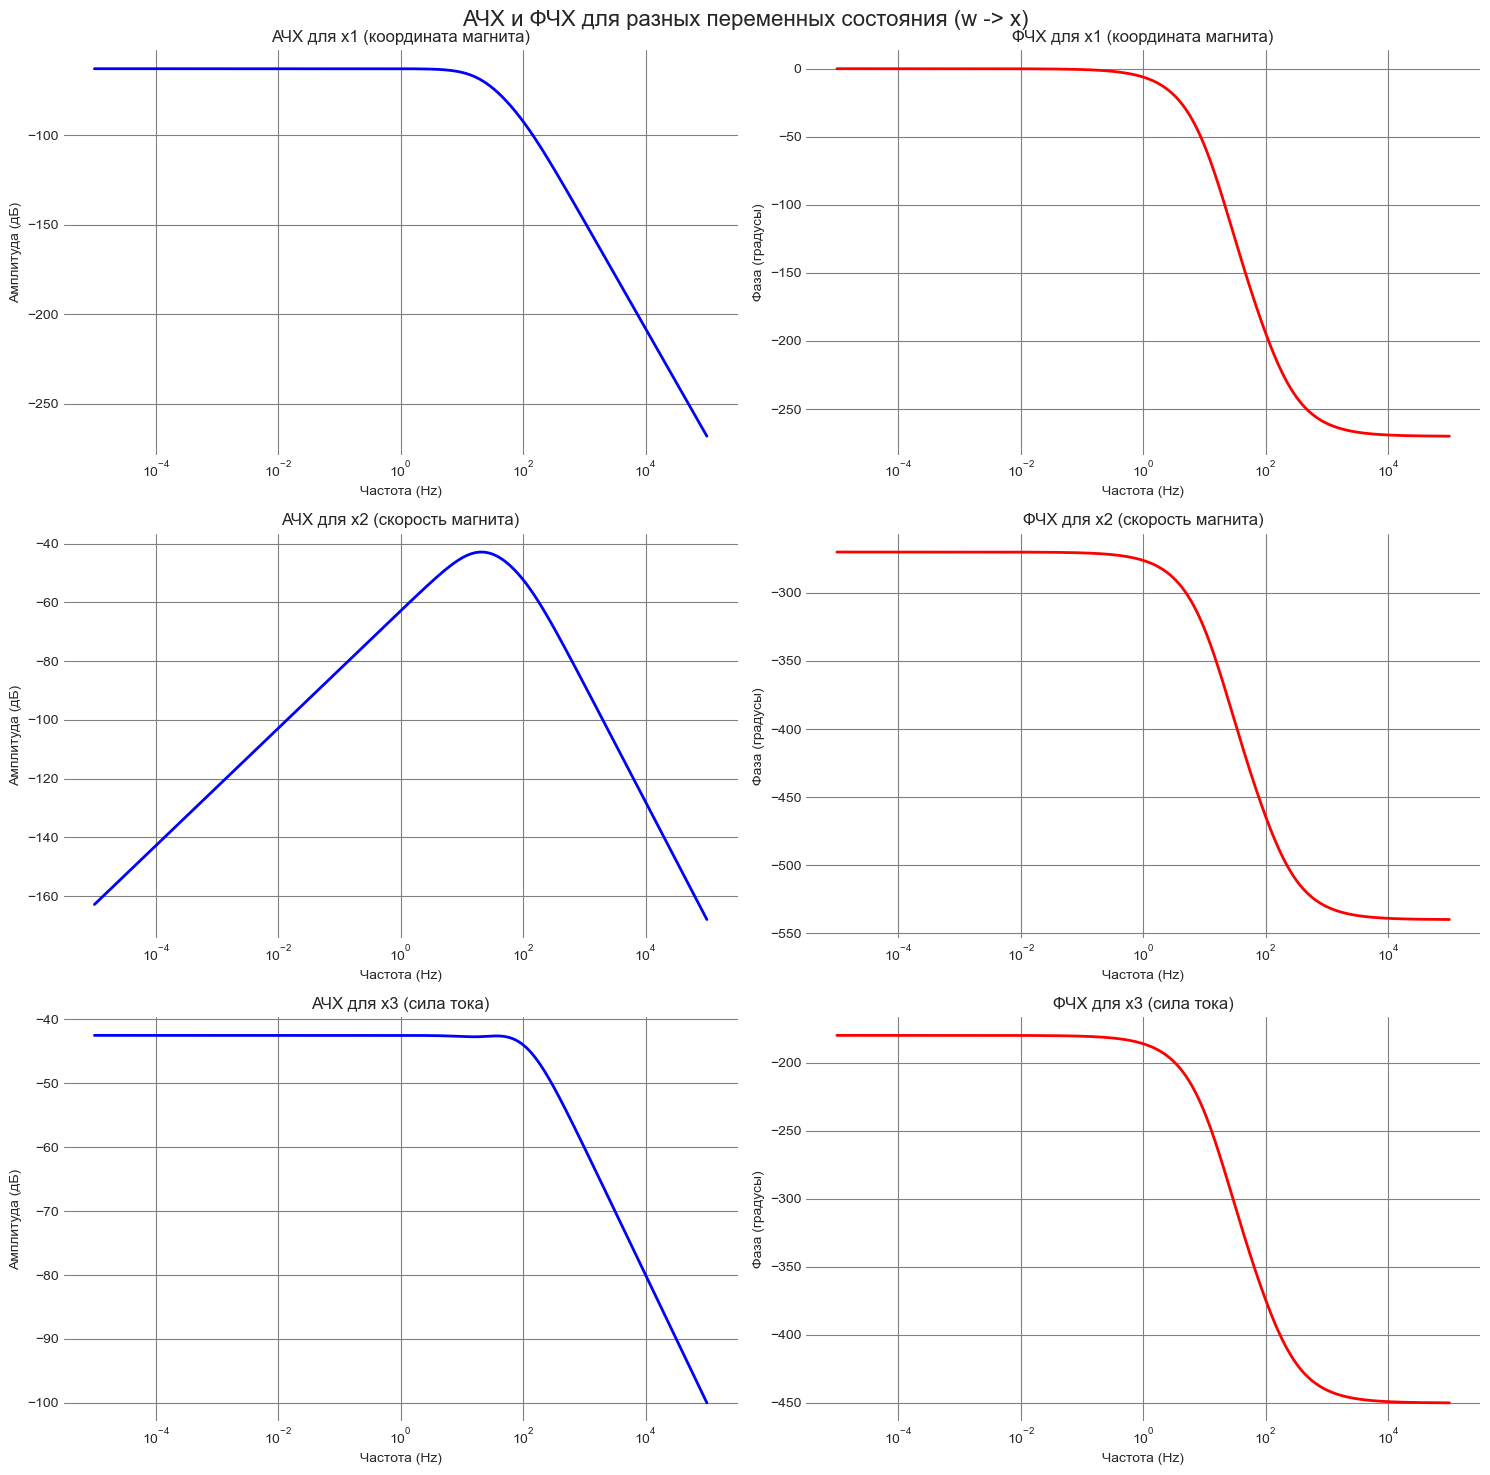

In [802]:
#АЧХ и ФЧХ x при ошибку в управлении
B_w = np.vstack([B, B])

sys_w_x1 = ct.ss(A_closed, B_w, C_x1_z, D)
sys_w_x2 = ct.ss(A_closed, B_w, C_x2_z, D)
sys_w_x3 = ct.ss(A_closed, B_w, C_x3_z, D)

fig, axes = plt.subplots(3, 2, figsize = (15, 15))
fig.suptitle('АЧХ и ФЧХ для разных переменных состояния (w -> x)', fontsize = 16)

for i in range(3):
    for j in range(2):
        axes[i, j].set_facecolor('none')
        axes[i, j].patch.set_alpha(0)

#Частотный диапазон
omega = np.logspace(-5, 5, 1000)

systems_w = [sys_w_x1, sys_w_x2, sys_w_x3]
titles = ['x1 (координата магнита)', 'x2 (скорость магнита)', 'x3 (сила тока)']

for i, (sys, title) in enumerate(zip(systems_w, titles)):

    mag, phase, omega = ct.bode(sys, omega, dB = True, Hz = True, plot = False)
    
    # График АЧХ
    axes[i, 0].semilogx(omega, 20 * np.log10(mag.flatten()), 'b-', linewidth=2)
    axes[i, 0].grid(True, color = 'gray')
    axes[i, 0].set_ylabel('Амплитуда (дБ)')
    axes[i, 0].set_title(f'АЧХ для {title}')
    axes[i, 0].set_xlabel('Частота (Hz)')
    
    # График ФЧХ
    axes[i, 1].semilogx(omega, phase.flatten() * 180/np.pi, 'r-', linewidth=2)
    axes[i, 1].grid(True, color = 'gray')
    axes[i, 1].set_ylabel('Фаза (градусы)')
    axes[i, 1].set_title(f'ФЧХ для {title}')
    axes[i, 1].set_xlabel('Частота (Hz)')

plt.tight_layout()
plt.show()

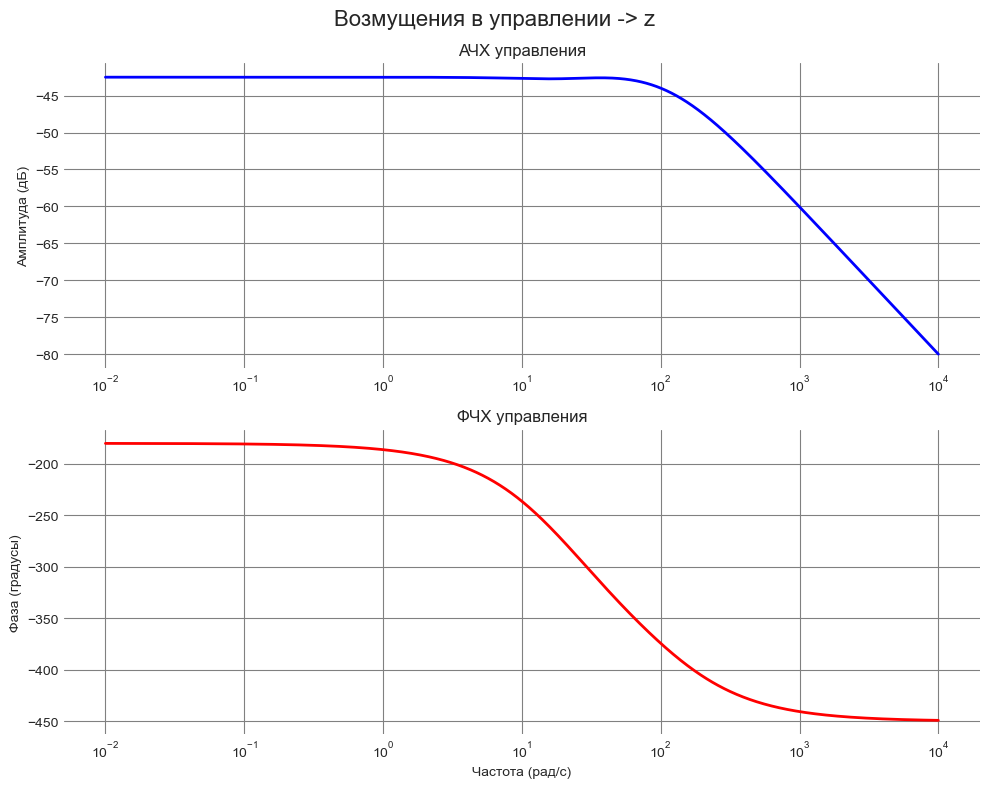

In [803]:
C_z = np.hstack([H, np.zeros((1, 3))])

sys_z = ct.ss(A_closed, B_w, C_z, D)

omega = np.logspace(-2, 4, 1000)  

mag_z, phase_z, omega_z = ct.bode(sys_z, omega, dB = True, Hz = True, plot = False)

fig, axes = plt.subplots(2, 1, figsize = (10, 8))
fig.suptitle('Возмущения в управлении -> z', fontsize = 16)

for i in range(2):
    axes[i].set_facecolor('none')
    axes[i].patch.set_alpha(0)

axes[0].semilogx(omega_z, 20*np.log10(mag_z.flatten()), 'b-', linewidth=2)
axes[0].grid(True, color = 'gray')
axes[0].set_ylabel('Амплитуда (дБ)')
axes[0].set_title('АЧХ управления')

axes[1].semilogx(omega_z, phase_z.flatten() * 180/np.pi, 'r-', linewidth=2)
axes[1].grid(True, color = 'gray')
axes[1].set_xlabel('Частота (рад/с)')
axes[1].set_ylabel('Фаза (градусы)')
axes[1].set_title('ФЧХ управления')

plt.tight_layout()
plt.show()